## Car Prediction Ml Model


In [111]:
# import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For Anova
import statsmodels.api as sm
from statsmodels.formula.api import ols

# For Ml model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , StandardScaler

# linear regression
from sklearn.linear_model import LinearRegression

# Random Forest regressor
from sklearn.ensemble import RandomForestRegressor

# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

# metrics
from sklearn.metrics import mean_squared_error, r2_score

# for Dump and Load
import joblib

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# view max cols
pd.set_option("display.max_columns", None)
pd.set_option('display.width', None)

print("All the Libraries imported ✔️")

All the Libraries imported ✔️


In [ ]:
# Load the Dataset
# Load the Dataset
data = pd.read_csv("car_price_prediction.csv")  # make sure this CSV is dowmloaded in your local system.

print(f"Car dataset had {data.shape[0]} rows and {data.shape[1]} columns")

Car dataset had 2500 rows and 10 columns


In [113]:
# lets check Datatype,Duplicates,Null values with sample
sample = data.head(5).T
sample = sample.rename(columns = {0:"sample_1",1:"sample_2",2:"sample_3",3:"sample_4",4:"sample_5"})
Null_duplicate = pd.DataFrame({"Dtypes":data.dtypes,
                               "Null Values":data.isnull().sum(),
                               "Duplicates":data.duplicated().sum()})
pd.concat([Null_duplicate,sample],axis=1)

,Dtypes,Null Values,Duplicates,sample_1,sample_2,sample_3,sample_4,sample_5
Car ID,int64,0,0,1,2,3,4,5
Brand,object,0,0,Tesla,BMW,Audi,Tesla,Ford
Year,int64,0,0,2016,2018,2013,2011,2009
Engine Size,float64,0,0,2.3,4.4,4.5,4.1,2.6
Fuel Type,object,0,0,Petrol,Electric,Electric,Diesel,Diesel
Transmission,object,0,0,Manual,Manual,Manual,Automatic,Manual
Mileage,int64,0,0,114832,143190,181601,68682,223009
Condition,object,0,0,New,Used,New,New,Like New
Price,float64,0,0,26613.92,14679.61,44402.61,86374.33,73577.1
Model,object,0,0,Model X,5 Series,A4,Model Y,Mustang


### Observations
- No Null values and Duplicates were in the Car dataset,Its a Clean Dataset.


In [114]:
# lets create some Functions we can use later

def value_counts(col):
    counts_in_numbers = data[col].value_counts(dropna=False)
    counts_in_percentage = round(data[col].value_counts(normalize=True,dropna=False)*100,2)
    values = pd.DataFrame({"Counts":counts_in_numbers,"Percentages":counts_in_percentage})
    values.loc["Total"]=values["Counts"].sum(),values["Percentages"].sum()

    return values


def outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR =  Q3 - Q1
    upper_range_value = Q3 + (1.5*IQR)
    lower_range_value = Q1 - (1.5*IQR)

    upper_outliers = data[data[col]>upper_range_value]
    lower_outliers = data[data[col]<lower_range_value]

    upper_outliers_counts = len(upper_outliers)
    lower_outliers_counts = len(lower_outliers)

    result_outliers  = pd.DataFrame([{"col":col,
                                     "Q1":Q1,
                                     "Q3":Q3,
                                     "IQR":IQR,
                                     "Upper Value":upper_range_value,
                                     "Lower Value":lower_range_value,
                                     "No.up_outliers":upper_outliers_counts,
                                     "No.lo_outliers":lower_outliers_counts
    }])
    return result_outliers


In [115]:
# Numerical and Categorical columns
nums_cols = []
cats_cols = []
for col in data.columns:
    if data[col].dtype == "O":
        cats_cols.append(col)
    else:
        nums_cols.append(col)
print(f"Total Columns : {data.shape[1]}\nNumerical columns : {len(nums_cols)} {nums_cols}\nCategorical columns : {len(cats_cols)} {cats_cols}")

Total Columns : 10
Numerical columns : 5 ['Car ID', 'Year', 'Engine Size', 'Mileage', 'Price']
Categorical columns : 5 ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']


In [116]:
# Value counts For Categorical columns
for col in cats_cols:
    values =  value_counts(col)
    print(f"Column Name: {col}\n{values}\n\n")

Column Name: Brand
          Counts  Percentages
Brand                        
Toyota     374.0        14.96
Audi       368.0        14.72
BMW        358.0        14.32
Mercedes   353.0        14.12
Honda      352.0        14.08
Tesla      348.0        13.92
Ford       347.0        13.88
Total     2500.0       100.00


Column Name: Fuel Type
           Counts  Percentages
Fuel Type                     
Diesel      655.0        26.20
Petrol      630.0        25.20
Electric    614.0        24.56
Hybrid      601.0        24.04
Total      2500.0       100.00


Column Name: Transmission
              Counts  Percentages
Transmission                     
Manual        1308.0        52.32
Automatic     1192.0        47.68
Total         2500.0       100.00


Column Name: Condition
           Counts  Percentages
Condition                     
Used        855.0        34.20
Like New    836.0        33.44
New         809.0        32.36
Total      2500.0       100.00


Column Name: Model
         

### Observations on categorical columns
- Toyota is the most common brand, followed by Audi and BMW, each around 14%.
- Diesel is the most popular fuel type, followed by Petrol and Electric. Hybrid cars are the least common.
- Manual cars are slightly more common than automatic ones, as drivers like more control.
- Cars are almost evenly distributed across conditions: Used, Like New, and New cars each about one-third.
- Fiesta and Corolla are the most common models, each about 4% of all cars.

In [117]:
# Outliers for Categorical columns
all_outliers = []
for col in nums_cols:
    result_outliers = outliers(col)
    all_outliers.append(result_outliers)

final_outliers = pd.concat(all_outliers, ignore_index=True)

print(final_outliers)


           col         Q1           Q3          IQR   Upper Value  \
0       Car ID    625.750    1875.2500    1249.5000    3749.50000   
1         Year   2005.000    2018.0000      13.0000    2037.50000   
2  Engine Size      2.200       4.7000       2.5000       8.45000   
3      Mileage  71831.500  225990.5000  154159.0000  457229.00000   
4        Price  28908.485   75838.5325   46930.0475  146233.60375   

    Lower Value  No.up_outliers  No.lo_outliers  
0   -1248.50000               0               0  
1    1985.50000               0               0  
2      -1.55000               0               0  
3 -159407.00000               0               0  
4  -41486.58625               0               0  


# observation
- No Outliers are there in the numerical columns.


In [118]:
value_counts("Year")

,Counts,Percentages
Year,,
2020,122.0,4.88
2016,118.0,4.72
2003,118.0,4.72
2022,112.0,4.48
2021,112.0,4.48
2012,111.0,4.44
2007,110.0,4.40
2002,110.0,4.40
2008,109.0,4.36


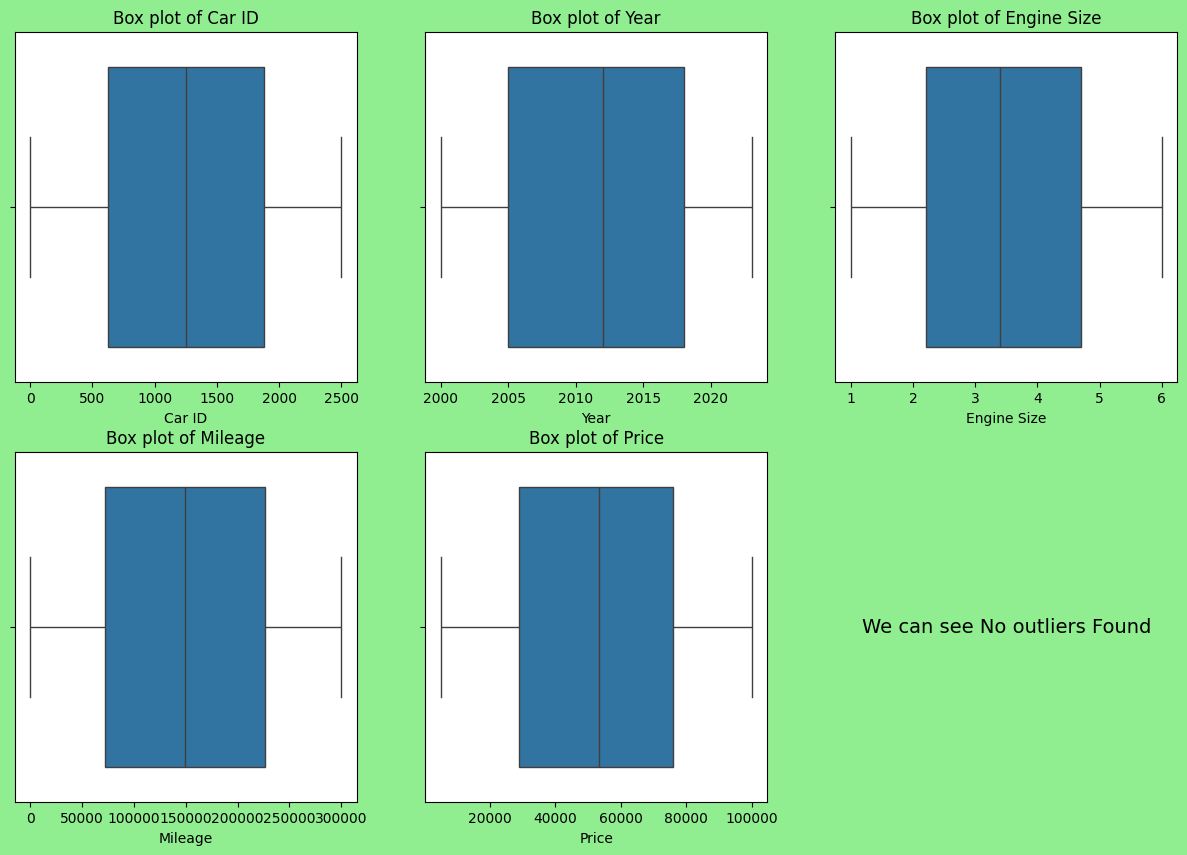

In [119]:
# Grpahical presntation of Outliers
fig , axes = plt.subplots(2,3,figsize = (15,10))
axes= axes.flatten()
fig.patch.set_facecolor("lightgreen")
for i,col in enumerate (nums_cols):
    sns.boxplot(x=data[col],ax=axes[i])
    axes[i].set_title(f"Box plot of {col}")

axes[5].axis('off')
axes[5].text(0.5, 0.5, "We can see No outliers Found", ha='center', va='center', fontsize=14)
plt.show()

In [120]:
# lets check More about the Numerical columns

Basic_raw_details = data[nums_cols].describe().T
print(Basic_raw_details)


              count           mean           std      min        25%  \
Car ID       2500.0    1250.500000    721.832160     1.00    625.750   
Year         2500.0    2011.626800      6.991700  2000.00   2005.000   
Engine Size  2500.0       3.465240      1.432053     1.00      2.200   
Mileage      2500.0  149749.844800  87919.952034    15.00  71831.500   
Price        2500.0   52638.022532  27295.833455  5011.27  28908.485   

                   50%          75%        max  
Car ID         1250.50    1875.2500    2500.00  
Year           2012.00    2018.0000    2023.00  
Engine Size       3.40       4.7000       6.00  
Mileage      149085.00  225990.5000  299967.00  
Price         53485.24   75838.5325   99982.59  


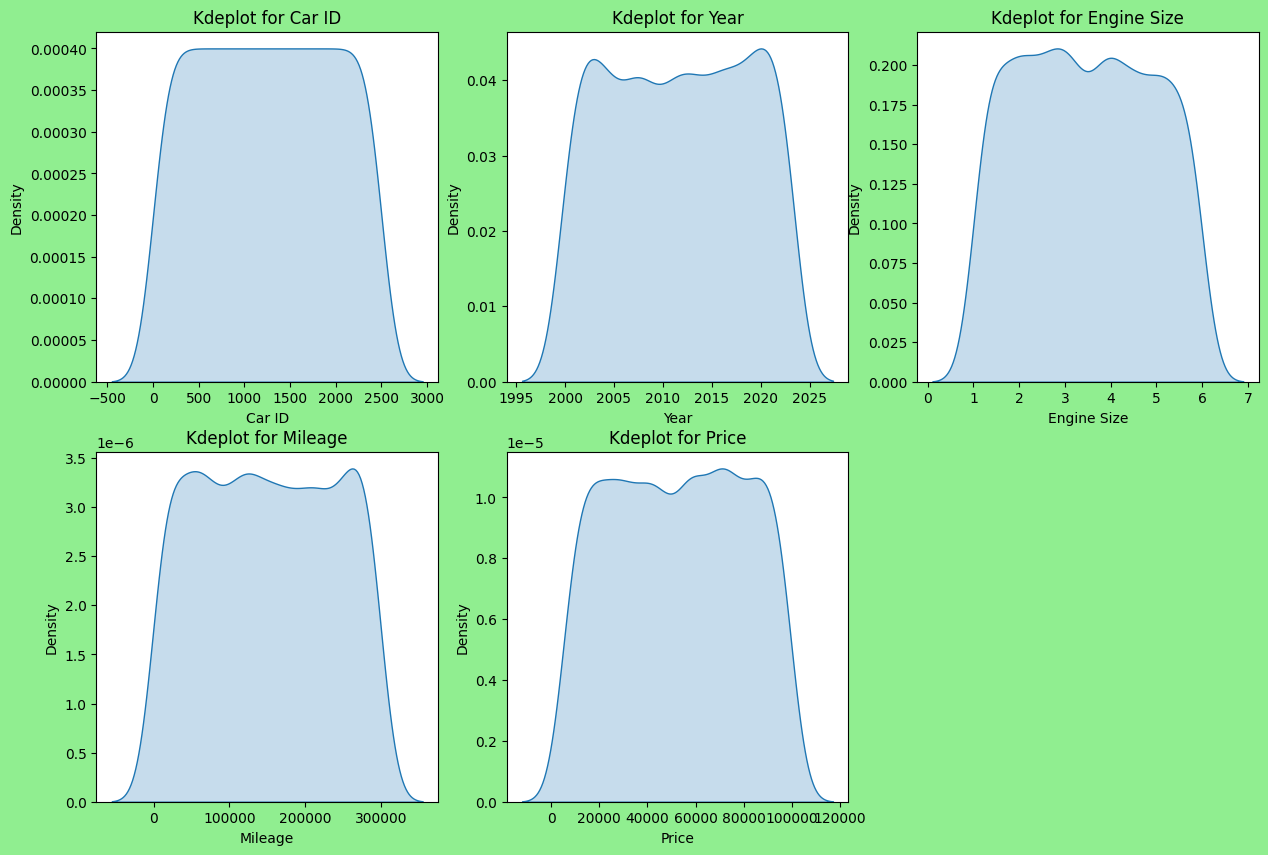

In [121]:
fig , axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.flatten()
fig.patch.set_facecolor("lightgreen")

for i , col in enumerate (nums_cols):
    sns.kdeplot(data=data,x=col,fill=True,ax=axes[i])
    axes[i].set_title(f"Kdeplot for {col}")
axes[5].axis("off")
plt.show()

### Observations on Numerical columns

- Car ID is just an identifier and is evenly spread, so it’s not meaningful for analysis.
- Cars come from years 2000 to 2023, spread fairly evenly across these years.
- Engine sizes range from 1.0 to 6.0 liters, with an average around 3.5 liters.
- Mileage varies a lot, from very low to very high, showing cars with different usage levels.
- Prices range from about $5,000 to $100,000, with a wide spread between budget and expensive cars.
- None of the columns follow a normal (bell-shaped) distribution; values are spread out or have multiple peaks.


In [122]:
# Statistics Checking
# 1.Anova
Anova_results = []
for col in cats_cols:
  model = ols(f"Price~C(Q('{col}'))",data=data).fit()
  anova_raw = sm.stats.anova_lm(model)
  Anova_results.append(anova_raw)
Anova_results

[                   df        sum_sq       mean_sq         F    PR(>F)
 C(Q('Brand'))     6.0  1.968037e+09  3.280062e+08  0.439647  0.852645
 Residual       2493.0  1.859943e+12  7.460663e+08       NaN       NaN,
                        df        sum_sq       mean_sq         F    PR(>F)
 C(Q('Fuel Type'))     3.0  5.573557e+09  1.857852e+09  2.498037  0.057961
 Residual           2496.0  1.856338e+12  7.437250e+08       NaN       NaN,
                           df        sum_sq       mean_sq         F    PR(>F)
 C(Q('Transmission'))     1.0  6.560606e+06  6.560606e+06  0.008802  0.925261
 Residual              2498.0  1.861905e+12  7.453582e+08       NaN       NaN,
                        df        sum_sq       mean_sq        F    PR(>F)
 C(Q('Condition'))     2.0  1.107613e+09  5.538067e+08  0.74315  0.475719
 Residual           2497.0  1.860804e+12  7.452157e+08      NaN       NaN,
                    df        sum_sq       mean_sq         F    PR(>F)
 C(Q('Model'))    27.0  2.14647

In [123]:
# 2.Correlation
data[nums_cols].corr()['Price']


,Price
Car ID,0.004650
Year,-0.036805
Engine Size,-0.004420
Mileage,-0.008567
Price,1.000000


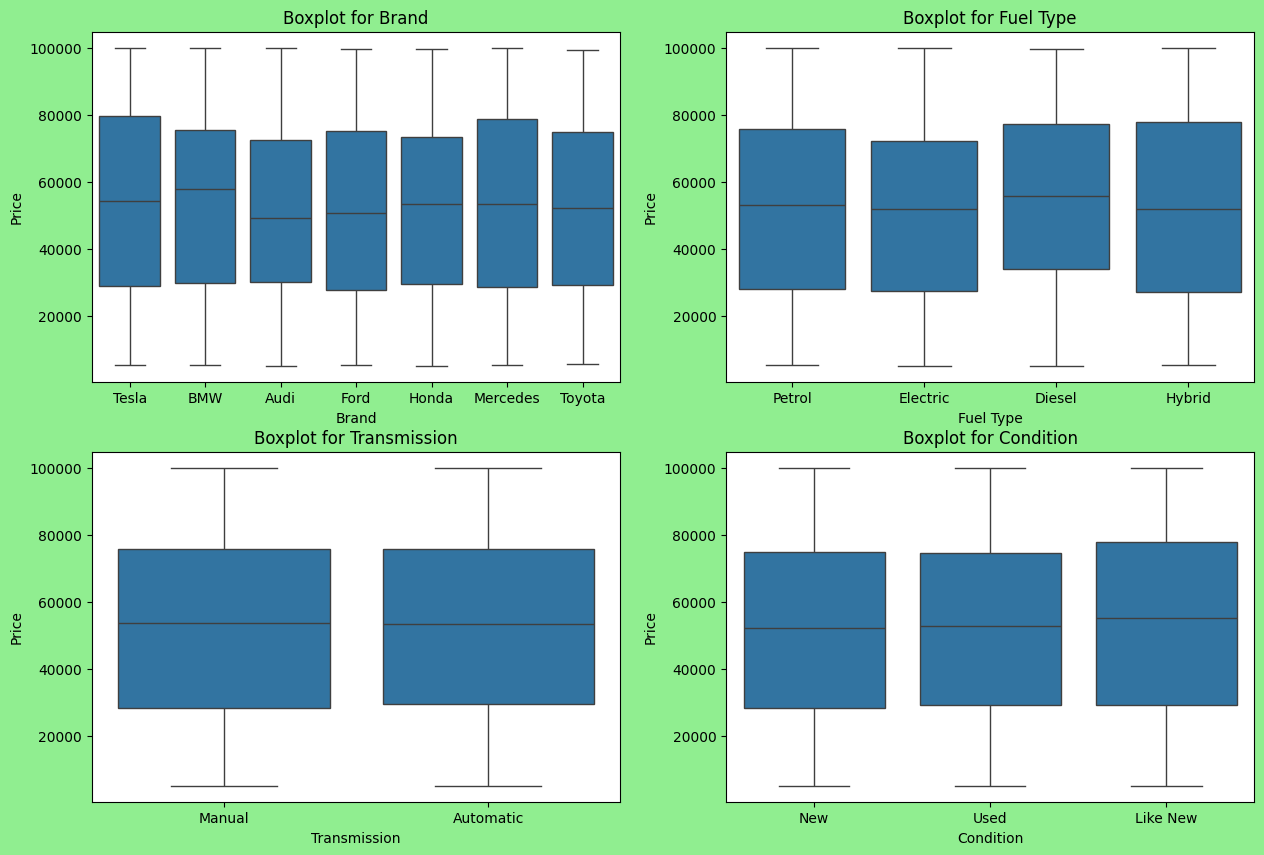

In [124]:
fig , axes = plt.subplots(2,2,figsize=(15,10))
axes = axes.flatten()
fig.patch.set_facecolor("lightgreen")
for i,col in enumerate (cats_cols):
  if col == "Model":
    continue
  else:
    sns.boxplot(x=col, y='Price', data=data,ax=axes[i])
    axes[i].set_title(f"Boxplot for {col}")


plt.show()

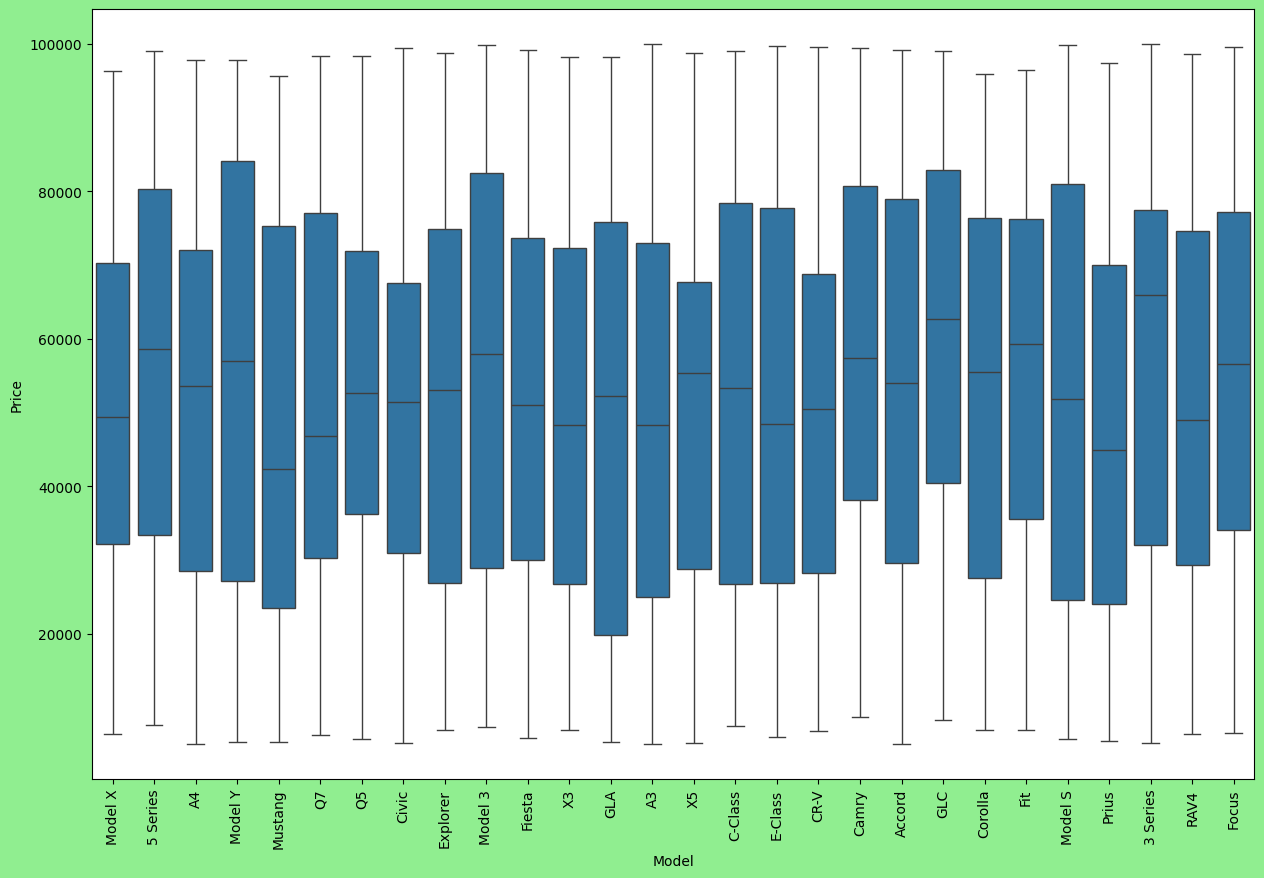

In [125]:
plt.figure(figsize=(15,10))
plt.gcf().set_facecolor("lightgreen")

sns.boxplot(x="Model", y='Price', data=data)
plt.xticks(rotation=90)
plt.show()

In [126]:
data.drop(columns = "Car ID",inplace= True)

## Observations

- Most categorical and numerical features have little to no impact on Price.
- Only Fuel Type shows a weak/borderline effect.
- we are dropping the Car Id as it is just a identifier.


In [127]:
# lets Build the ML Model

# Dependency split
X = data[[ 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission','Mileage', 'Condition',  'Model']]
Y = data['Price']

In [128]:
# train test split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

# Dimensions Check
print(f"Training Data: X-Train:{X_train.shape},Y-Train:{Y_train.shape}")
print(f"Testing Data: X-Test:{X_test.shape},Y-Test:{Y_test.shape}")


Training Data: X-Train:(2000, 8),Y-Train:(2000,)
Testing Data: X-Test:(500, 8),Y-Test:(500,)


In [129]:
X_train.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model
2055,Mercedes,2005,3.4,Electric,Automatic,73401,New,C-Class
1961,BMW,2004,1.6,Diesel,Manual,252234,New,5 Series
1864,Tesla,2002,5.8,Diesel,Manual,89882,Like New,Model X
2326,Mercedes,2000,4.6,Diesel,Manual,275333,New,GLC
461,Honda,2010,3.2,Diesel,Manual,41190,Like New,CR-V


In [130]:
X_test.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model
1447,Honda,2010,3.0,Diesel,Manual,211864,Like New,Fit
1114,Tesla,2020,4.4,Hybrid,Manual,18781,Like New,Model 3
1064,Toyota,2013,4.3,Diesel,Manual,55547,Like New,RAV4
2287,Toyota,2006,3.0,Hybrid,Automatic,196914,Used,Camry
1537,BMW,2016,5.5,Petrol,Automatic,67764,Like New,5 Series


In [131]:
# check the unique items
for col in X_train[cats_cols]:
  print(f"{col}-{X_train[col].nunique()}")

Brand-7
Fuel Type-4
Transmission-2
Condition-3
Model-28


In [132]:
# Encoding
encoder = OneHotEncoder(sparse_output=False,drop="first",dtype="i")

# Training Data
X_train_encode = encoder.fit_transform(X_train[cats_cols])
X_train_encode = pd.DataFrame(X_train_encode,columns = encoder.get_feature_names_out(cats_cols),index=X_train.index)
X_train_encode = pd.concat([X_train.drop(columns =cats_cols),X_train_encode],axis = 1)

print(f"After Encoding the shape of Training data : {X_train_encode.shape}")

# Testing Data
X_test_encode = encoder.transform(X_test[cats_cols])
X_test_encode = pd.DataFrame(X_test_encode,columns= encoder.get_feature_names_out(cats_cols),index=X_test.index)
X_test_encode = pd.concat([X_test.drop(columns = cats_cols),X_test_encode],axis =1 )

print(f"After Encoding the shape of Testing data : {X_test_encode.shape}")

After Encoding the shape of Training data : (2000, 42)
After Encoding the shape of Testing data : (500, 42)


In [133]:
X_train_encode.head()

,Year,Engine Size,Mileage,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Transmission_Manual,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
2055,2005,3.4,73401,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1961,2004,1.6,252234,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1864,2002,5.8,89882,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2326,2000,4.6,275333,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
461,2010,3.2,41190,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [134]:
# Scaling
scaler = StandardScaler()

# training
X_train_scaling = scaler.fit_transform(X_train_encode[['Year','Engine Size','Mileage']])
X_train_scaling = pd.DataFrame(X_train_scaling,columns = ['Year','Engine Size','Mileage'],index=X_train.index)

print(f"Shape of Training after Scaling:{X_train_scaling.shape}")

# testing
X_test_scaling = scaler.transform(X_test_encode[['Year','Engine Size','Mileage']])
X_test_scaling = pd.DataFrame(X_test_scaling,columns = ['Year','Engine Size','Mileage'] ,index= X_test.index)

print(f"Shape of Testing after Scaling:{X_test_scaling.shape}")


Shape of Training after Scaling:(2000, 3)
Shape of Testing after Scaling:(500, 3)


In [135]:
# final Data
X_train_final = pd.concat([X_train_scaling,X_train_encode.drop(columns=['Year','Engine Size','Mileage'])],axis =1 )
X_test_final = pd.concat([X_test_scaling,X_test_encode.drop(columns=['Year','Engine Size','Mileage'])],axis =1 )

print(f"Final Data shape after Encoding and scaling is {X_train_final.shape} and {X_test_final.shape}")

Final Data shape after Encoding and scaling is (2000, 42) and (500, 42)


In [136]:
X_train_final.head()

,Year,Engine Size,Mileage,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Transmission_Manual,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
2055,-0.940027,-0.040969,-0.883145,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1961,-1.083685,-1.302642,1.153363,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1864,-1.371001,1.641261,-0.695464,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2326,-1.658318,0.800146,1.416409,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
461,-0.221736,-0.181155,-1.249957,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [137]:
# lets do the Modeling
#1.Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train_final,Y_train)
print(f"Linear Model Trained✔️")
# predict
linear_model_pred = linear_model.predict(X_test_final)

# Evaluate
linear_rmse = mean_squared_error(Y_test, linear_model_pred)
linear_rmse = np.sqrt(linear_rmse)
linear_r2 = r2_score(Y_test, linear_model_pred)

print(f"Linear RMSE :{linear_rmse}\nLinear R2 :{linear_r2}")

Linear Model Trained✔️
Linear RMSE :27794.413123934624
Linear R2 :-0.019768995768102426


In [138]:
# Random Forest Regressor
forest_model = RandomForestRegressor()

forest_model.fit(X_train_final,Y_train)
print(f"Forest Model Trained✔️")
# predict
forest_model_pred = forest_model.predict(X_test_final)

# Evaluate
forest_rmse = mean_squared_error(Y_test,forest_model_pred)
forest_rmse = np.sqrt(forest_rmse)
forest_r2 = r2_score(Y_test,forest_model_pred)

print(f"Forest RMSE :{forest_rmse}\nForest R2 :{forest_r2}")

Forest Model Trained✔️
Forest RMSE :28651.477128572224
Forest R2 :-0.08362950391120028


In [139]:
# gradient Boost
gradient_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gradient_model.fit(X_train_final,Y_train)
print(f"Gradient Model Trained✔️")
# predict
gradient_model_pred = gradient_model.predict(X_test_final)

# Evaluate
gradient_rmse = mean_squared_error(Y_test,gradient_model_pred)
gradient_rmse=np.sqrt(gradient_rmse)
gradient_r2 = r2_score(Y_test,gradient_model_pred)

print(f"Gradient RMSE :{gradient_rmse}\nGradient R2 :{gradient_r2}")

Gradient Model Trained✔️
Gradient RMSE :28447.873239207205
Gradient R2 :-0.06828319188317988


In [140]:
# Check Feature importance
Forest_importance = pd.Series(forest_model.feature_importances_,index=X_train_final.columns)
Gradient_importance = pd.Series(gradient_model.feature_importances_,index=X_train_final.columns)

# Combine in a DataFrame
final_feature_importance = pd.DataFrame({
    "Random Forest": Forest_importance,
    "Gradient Boosting": Gradient_importance
}).sort_values(by="Gradient Boosting", ascending=False)

final_feature_importance.head(10)

,Random Forest,Gradient Boosting
Mileage,0.254047,0.359615
Engine Size,0.174166,0.155675
Year,0.141201,0.147999
Transmission_Manual,0.027442,0.026755
Fuel Type_Hybrid,0.021347,0.021716
Condition_New,0.023496,0.018128
Model_Model Y,0.009995,0.016570
Model_E-Class,0.008352,0.014577
Model_C-Class,0.011829,0.014168
Fuel Type_Electric,0.021068,0.014030


## Final Observations
- "Linear Regression": "Simple and interpretable; predicts worse than mean."
- "Random Forest": "Handles non-linear data; still poor due to weak features."
- "Gradient Boosting": "Most advanced model; features too weak, predicts near mean."


In [141]:
joblib.dump(linear_model,"car_linear_model.pkl")
joblib.dump(forest_model,"car_forest_model.pkl")
joblib.dump(gradient_model,"car_gradient_model.pkl")
print(f"Linear Model Stored✔️\nForest Model Stored✔️\nGradient Model Stored✔️")

Linear Model Stored✔️
Forest Model Stored✔️
Gradient Model Stored✔️
